In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/final_weather.csv")
df['datetime'] = pd.to_datetime(df['datetime'])

print(df.shape)
print(df.info())
print(df.describe())

(90648, 24)
<class 'pandas.DataFrame'>
RangeIndex: 90648 entries, 0 to 90647
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   datetime         90648 non-null  datetime64[us]
 1   temperature_C    90648 non-null  float64       
 2   humidity_pct     90648 non-null  float64       
 3   feels_like_C     90648 non-null  float64       
 4   rainfall_mm      90648 non-null  float64       
 5   wind_speed_kmh   90648 non-null  float64       
 6   wind_dir_deg     90648 non-null  float64       
 7   pressure_hpa     90648 non-null  float64       
 8   cloud_cover_pct  90648 non-null  float64       
 9   visibility_km    0 non-null      float64       
 10  dew_point_C      90648 non-null  float64       
 11  solar_rad_Wm2    90648 non-null  float64       
 12  is_daytime       90648 non-null  float64       
 13  year             90648 non-null  int64         
 14  month            90648 non-null  int6

In [ ]:
df = df.drop(columns=['visibility_km'])

In [ ]:
df = df.sort_values('datetime')
df.set_index('datetime', inplace=True)

print(df.index.min(), "→", df.index.max())

2016-01-01 00:00:00 → 2026-05-04 23:00:00


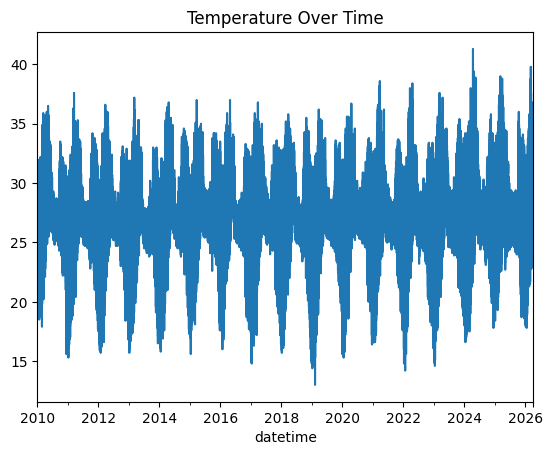

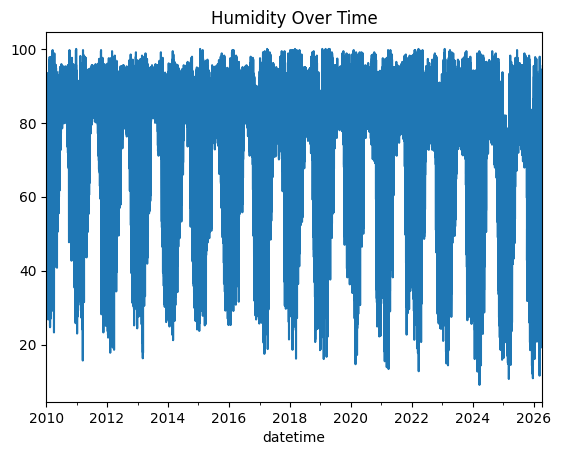

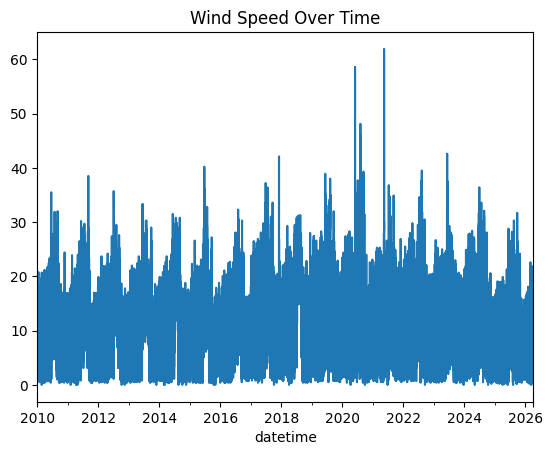

In [ ]:
df['temperature_C'].plot(title="Temperature Over Time")
plt.show()

df['humidity_pct'].plot(title="Humidity Over Time")
plt.show()

df['wind_speed_kmh'].plot(title="Wind Speed Over Time")
plt.show()

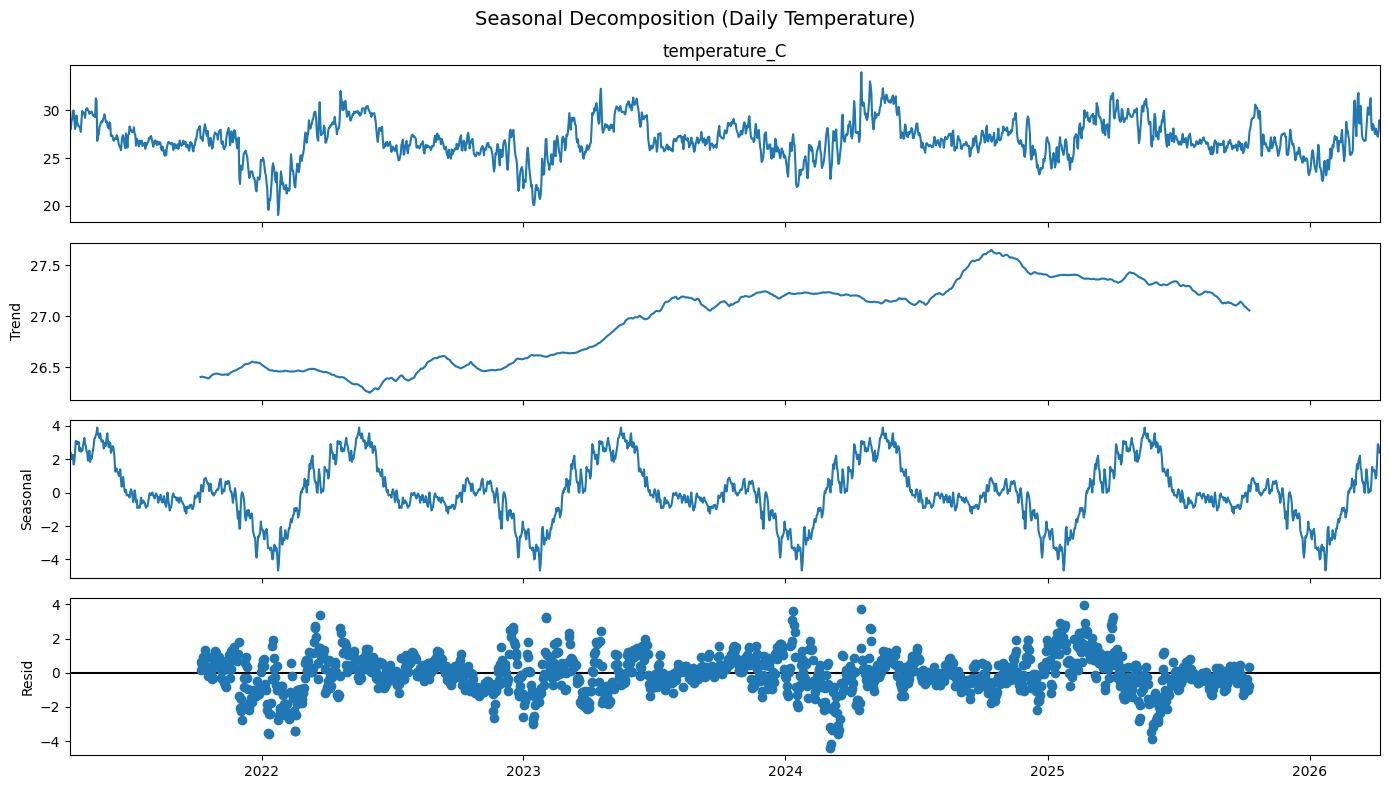

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

# -----------------------------
# ✅ 1. Handle datetime properly
# -----------------------------
if 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')
    df = df.dropna(subset=['datetime'])
    df = df.set_index('datetime')
else:
    # Already index → just ensure correct format
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[~df.index.isna()]

# Sort index
df = df.sort_index()

# -----------------------------
# ✅ 2. Resample (hourly → daily)
# -----------------------------
daily_temp = df['temperature_C'].resample('D').mean()

# -----------------------------
# ✅ 3. Take last 5 years
# -----------------------------
daily_temp = daily_temp.loc[
    daily_temp.index >= daily_temp.index.max() - pd.DateOffset(years=5)
]

# -----------------------------
# ✅ 4. Decomposition
# -----------------------------
result = seasonal_decompose(
    daily_temp,
    model='additive',
    period=365
)

# -----------------------------
# ✅ 5. Plot
# -----------------------------
fig = result.plot()
fig.set_size_inches(14, 8)

plt.suptitle("Seasonal Decomposition (Daily Temperature)", fontsize=14)
plt.tight_layout()
plt.show()

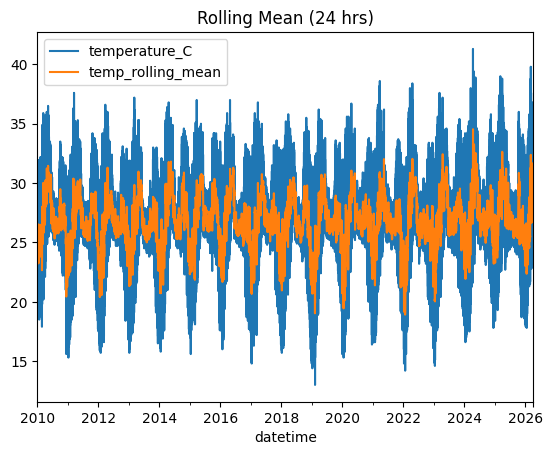

In [9]:
df['temp_rolling_mean'] = df['temperature_C'].rolling(window=24).mean()

df[['temperature_C', 'temp_rolling_mean']].plot(title="Rolling Mean (24 hrs)")
plt.show()

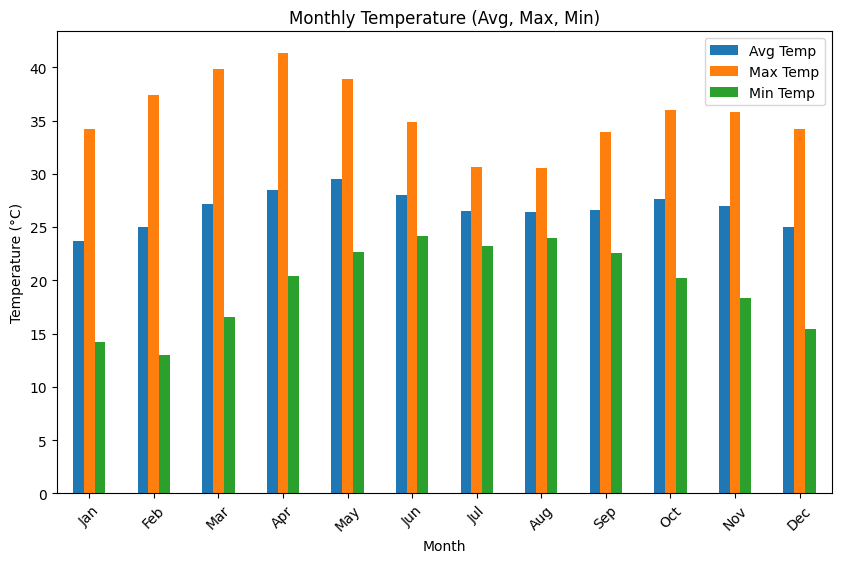

In [ ]:
import matplotlib.pyplot as plt

# Group data
monthly_stats = df.groupby('month')['temperature_C'].agg(['mean', 'max', 'min'])

# Month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

monthly_stats.index = month_names

# Plot

monthly_stats.plot(kind='bar', figsize=(10,6))
plt.title("Monthly Temperature (Avg, Max, Min)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=45)
plt.legend(['Avg Temp', 'Max Temp', 'Min Temp'])

plt.show()

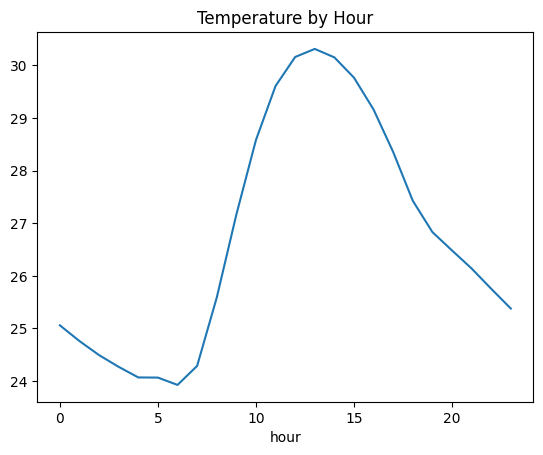

In [11]:
hourly_avg = df.groupby('hour')['temperature_C'].mean()

hourly_avg.plot(kind='line', title="Temperature by Hour")
plt.show()


📊 Correlation Matrix:

                 temperature_C  humidity_pct  feels_like_C  rainfall_mm  \
temperature_C             1.00         -0.42          0.89        -0.04   
humidity_pct             -0.42          1.00         -0.01         0.25   
feels_like_C              0.89         -0.01          1.00         0.01   
rainfall_mm              -0.04          0.25          0.01         1.00   
wind_speed_kmh            0.23         -0.01          0.06         0.27   
pressure_hpa             -0.26         -0.46         -0.42        -0.34   
cloud_cover_pct           0.00          0.50          0.18         0.33   
dew_point_C               0.25          0.76          0.61         0.21   
solar_rad_Wm2             0.67         -0.59          0.49        -0.10   

                 wind_speed_kmh  pressure_hpa  cloud_cover_pct  dew_point_C  \
temperature_C              0.23         -0.26             0.00         0.25   
humidity_pct              -0.01         -0.46             0.50     

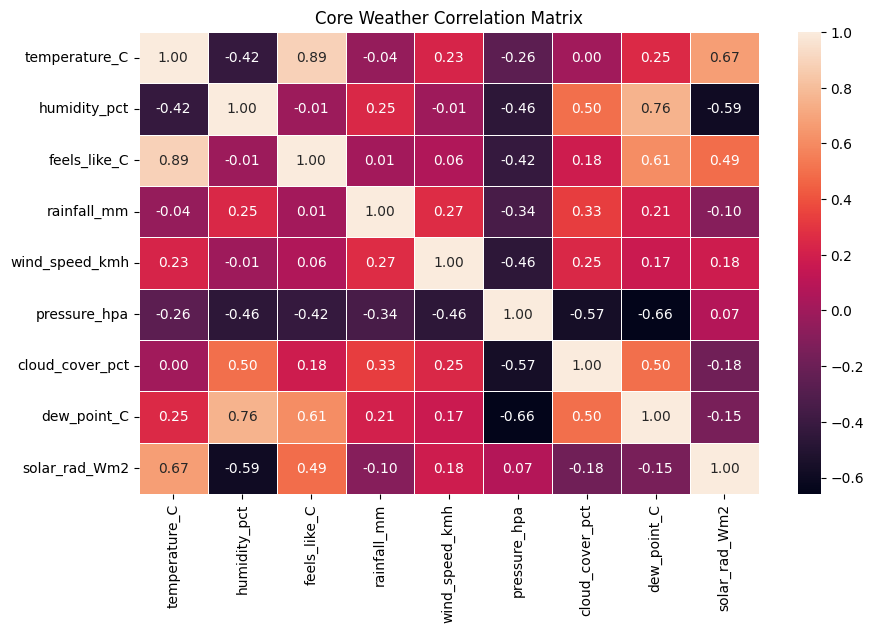

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cols = [
    'temperature_C',
    'humidity_pct',
    'feels_like_C',
    'rainfall_mm',
    'wind_speed_kmh',
    'pressure_hpa',
    'cloud_cover_pct',
    'dew_point_C',
    'solar_rad_Wm2'
]

# ✅ Correlation matrix
corr = df[cols].corr()

# -----------------------------
# 🧾 Print matrix values
# -----------------------------
print("\n📊 Correlation Matrix:\n")
print(corr.round(2))

# -----------------------------
# 🎨 Plot heatmap
# -----------------------------
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)

plt.title("Core Weather Correlation Matrix")
plt.show()

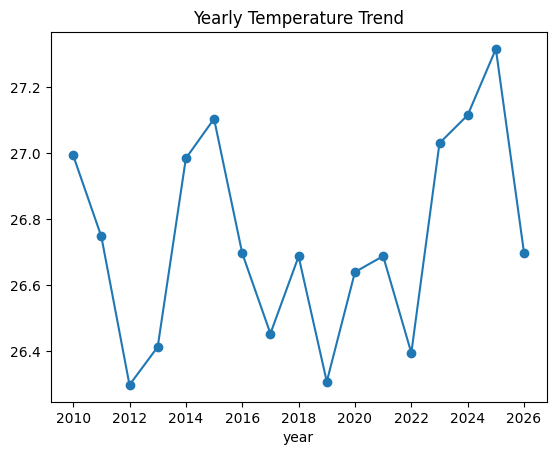

In [15]:
yearly_avg = df.groupby('year')['temperature_C'].mean()

yearly_avg.plot(marker='o', title="Yearly Temperature Trend")
plt.show()

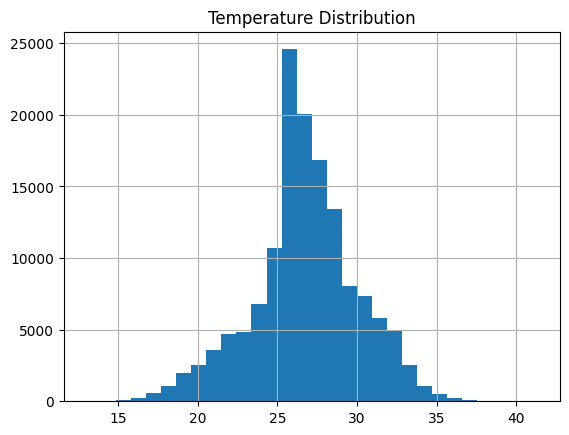

In [ ]:
df['temperature_C'].hist(bins=30)
plt.title("Temperature Distribution")
plt.show()

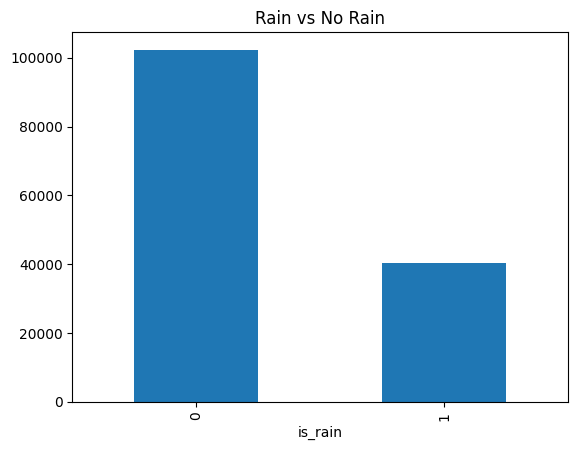

In [17]:
rain_counts = df['is_rain'].value_counts()

rain_counts.plot(kind='bar', title="Rain vs No Rain")
plt.show()

In [ ]:
print("Max Temp:", df['temperature_C'].max())
print("Min Temp:", df['temperature_C'].min())

print("Max Wind:", df['wind_speed_kmh'].max())

Max Temp: 41.3
Min Temp: 13.0
Max Wind: 61.9


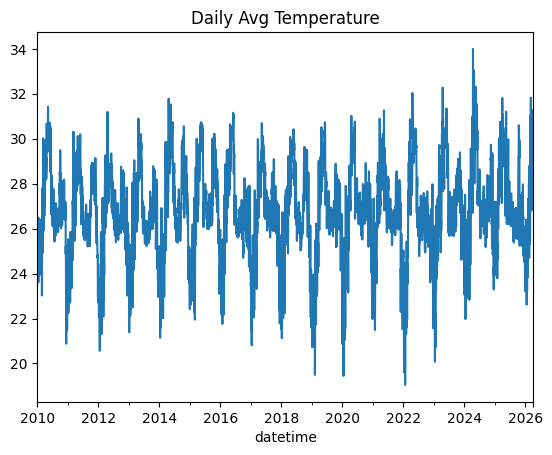

In [20]:
daily_temp = df['temperature_C'].resample('D').mean()
daily_temp.plot(title="Daily Avg Temperature")
plt.show()

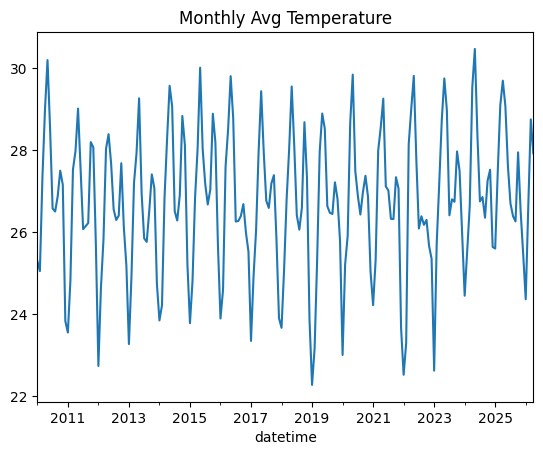

In [ ]:
monthly_temp = df['temperature_C'].resample('ME').mean()
monthly_temp.plot(title="Monthly Avg Temperature")
plt.show()

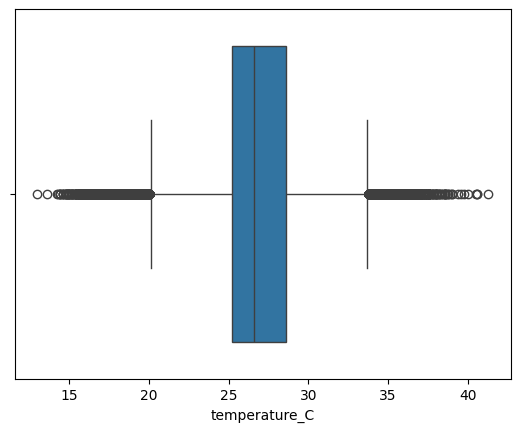

In [23]:
sns.boxplot(x=df['temperature_C'])
plt.show()

1. Data overview
2. Missing value analysis
3. Time index validation
4. Trend analysis
5. Seasonality (hourly, monthly)
6. Correlation
7. Distribution
8. Outliers
9. Resampling (daily/monthly)
10. Feature insights